2026-01-06 10:33:56.161552: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767695636.336049      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767695636.385023      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767695636.797342      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767695636.797376      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767695636.797379      24 computation_placer.cc:177] computation placer alr

Bắt đầu cài đặt môi trường và các thư viện cần thiết...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.1/162.1 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 3.20.3 which is incompatible.
onnx 1.20.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
ray 2.52.1 requires click!=8.3.*,>=7.0, but you have click 8.3.1 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
tensorflow-metadata 1.17.2 requires protobuf>=4.25.2; python_version >= "3.11", but you have protobuf 3.20.3 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 3.20.3 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
grpcio-status 1.71.2 requires

Thiết lập VnCoreNLP để tách từ Tiếng Việt...
2026-01-06 10:34:31 INFO  WordSegmenter:24 - Loading Word Segmentation model
Bắt đầu thực thi kịch bản pre-training với phương pháp CLM.


tokenizer_config.json:   0%|          | 0.00/417 [00:00<?, ?B/s]

...

Đang tải dữ liệu từ các tệp nguồn...


model.safetensors:   0%|          | 0.00/462M [00:00<?, ?B/s]

Đã tải thành công 37,269 câu từ kho dữ liệu.
Thêm 11221 token mới vào vocabulary của tokenizer.


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`



Đang nối các câu lại với độ dài tối đa=64...
  - Số câu gốc: 37,269 -> Số mẫu sau khi nối: 11,114

Đang tokenize 11,114 mẫu...

Thực hiện kiểm tra nhanh trên data collator...
  - Tỷ lệ mask của batch mẫu: 28.0%
  - Tỷ lệ mask nằm trong khoảng mong đợi.

Bắt đầu huấn luyện với phương pháp Masking Cấp độ Ký tự (CLM)...
  - Thiết bị sử dụng: cuda
  - Số batch mỗi epoch: 348
  - Tổng số bước huấn luyện: 34800

Epoch 1/100 | Loss: 4.1944 | Ghi nhận mô hình tốt nhất mới.
Epoch 2/100 | Loss: 3.4770 | Ghi nhận mô hình tốt nhất mới.
Epoch 3/100 | Loss: 3.2484 | Ghi nhận mô hình tốt nhất mới.
Epoch 4/100 | Loss: 3.1034 | Ghi nhận mô hình tốt nhất mới.
Epoch 5/100 | Loss: 2.9965 | Ghi nhận mô hình tốt nhất mới.
Epoch 6/100 | Loss: 2.8846 | Ghi nhận mô hình tốt nhất mới.
Epoch 7/100 | Loss: 2.7959 | Ghi nhận mô hình tốt nhất mới.
Epoch 8/100 | Loss: 2.7149 | Ghi nhận mô hình tốt nhất mới.
Epoch 9/100 | Loss: 2.6489 | Ghi nhận mô hình tốt nhất mới.
Epoch 10/100 | Loss: 2.5795 | Ghi nhận mô hình tố

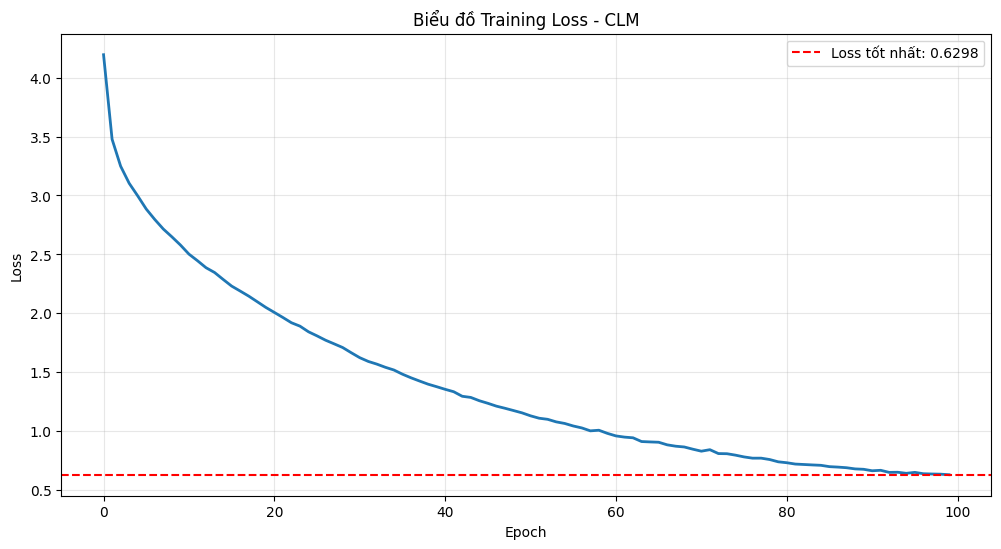

In [1]:
import os
import matplotlib.pyplot as plt
import random
import ast
import string
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (BertTokenizer, BertForMaskedLM, get_linear_schedule_with_warmup)

# --- CÁC THAM SỐ CẤU HÌNH ---
FILE_CORPUS = "/kaggle/input/final-prj-nlp/final_train.xlsx"
FILE_BIG_DICT = "/kaggle/input/final-prj-nlp/QuocNgu_SinoNom_Dic.xlsx"
FILE_SIMILAR = "/kaggle/input/final-prj-nlp/SinoNom_similar_Dic.xlsx"
OUTPUT_DIR = "/kaggle/working/final"
MODEL_NAME = "Jihuai/bert-ancient-chinese"

# --- KHỞI TẠO MÔI TRƯỜNG ---
print("Bắt đầu cài đặt môi trường và các thư viện cần thiết...")
os.system('apt-get install -y openjdk-11-jdk-headless -qq > /dev/null')
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.system('pip install -q py-vncorenlp pandas openpyxl transformers torch protobuf==3.20.3')

import py_vncorenlp

print("Thiết lập VnCoreNLP để tách từ Tiếng Việt...")
VNCORENLP_DIR = '/kaggle/working/vncorenlp_models'
if not os.path.exists(VNCORENLP_DIR): os.makedirs(VNCORENLP_DIR)
# Tải các file cần thiết cho VnCoreNLP nếu chưa tồn tại
if not os.path.exists(os.path.join(VNCORENLP_DIR, 'VnCoreNLP-1.2.jar')):
    os.system(f'wget -q -O {VNCORENLP_DIR}/VnCoreNLP-1.2.jar https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/VnCoreNLP-1.2.jar')
    models_dir = os.path.join(VNCORENLP_DIR, 'models', 'wordsegmenter')
    os.makedirs(models_dir, exist_ok=True)
    os.system(f'wget -q -O {models_dir}/vi-vocab https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/vi-vocab')
    os.system(f'wget -q -O {models_dir}/wordsegmenter.rdr https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master/models/wordsegmenter/wordsegmenter.rdr')
rdrsegmenter = py_vncorenlp.VnCoreNLP(save_dir=VNCORENLP_DIR, annotators=["wseg"])

# --- CÁC HÀM XỬ LÝ DỮ LIỆU ---

class PureCLMCollator:
    """
    Data collator thực hiện việc mask thuần túy ở cấp độ ký tự (Character-Level Masking - CLM).
    Chiến lược này mask các ký tự riêng lẻ một cách ngẫu nhiên, không quan tâm đến các từ ghép.
    Phương pháp này phù hợp cho các tác vụ như sửa lỗi OCR hoặc cải thiện nhận dạng ký tự.
    """
    def __init__(self, tokenizer, mlm_probability=0.3):
        self.tokenizer = tokenizer
        self.mlm_probability = mlm_probability
        self.total_masked = 0
        self.total_tokens = 0
        
    def __call__(self, examples):
        input_ids = torch.stack([e['input_ids'] for e in examples])
        attention_mask = torch.stack([e['attention_mask'] for e in examples])
        labels = input_ids.clone()
        
        batch_size, seq_len = input_ids.shape
        
        special_ids = {
            self.tokenizer.cls_token_id,
            self.tokenizer.sep_token_id,
            self.tokenizer.pad_token_id,
            self.tokenizer.unk_token_id
        }
        
        for i in range(batch_size):
            # Xác định tất cả các vị trí token có thể được mask trong câu.
            maskable_positions = [j for j, token_id in enumerate(input_ids[i]) if token_id.item() not in special_ids]
            
            if not maskable_positions:
                labels[i] = -100
                continue
            
            # Xác định số lượng token cần mask và lựa chọn ngẫu nhiên.
            num_to_mask = max(1, int(len(maskable_positions) * self.mlm_probability))
            selected_positions = random.sample(maskable_positions, min(num_to_mask, len(maskable_positions)))
            
            # Áp dụng quy tắc masking 80-10-10.
            for pos in selected_positions:
                rand_val = random.random()
                if rand_val < 0.8:
                    # 80% trường hợp thay bằng [MASK]
                    input_ids[i, pos] = self.tokenizer.mask_token_id
                elif rand_val < 0.9:
                    # 10% trường hợp thay bằng một token ngẫu nhiên
                    random_token_id = random.randint(0, len(self.tokenizer) - 1)
                    while random_token_id in special_ids:
                        random_token_id = random.randint(0, len(self.tokenizer) - 1)
                    input_ids[i, pos] = random_token_id
                # 10% còn lại giữ nguyên token gốc
            
            # Thiết lập nhãn (labels) để tính loss, bỏ qua các token không được mask bằng cách gán giá trị -100.
            for j in range(seq_len):
                if j not in selected_positions:
                    labels[i, j] = -100
                else:
                    self.total_masked += 1
            
            self.total_tokens += len(maskable_positions)
        
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }
    
    def print_stats(self):
        """In ra thống kê cuối cùng về việc masking."""
        if self.total_tokens > 0:
            pct = self.total_masked / self.total_tokens * 100
            print(f"\nThống kê masking: Tổng cộng {self.total_masked:,} tokens đã được mask trên tổng số {self.total_tokens:,} ({pct:.1f}%).")

def load_data():
    print("Đang tải dữ liệu từ các tệp nguồn...")
    try:
        df_big = pd.read_excel(FILE_BIG_DICT)
        dict_nom = dict(zip(df_big.iloc[:, 1].astype(str).str.strip(), 
                            df_big.iloc[:, 0].astype(str).str.strip()))
    except Exception as e:
        print(f"Cảnh báo: Không thể tải từ điển Hán Nôm. Lỗi: {e}")
        dict_nom = {}
    
    try:
        df_sim = pd.read_excel(FILE_SIMILAR)
        similar_dict = {}
        for _, row in df_sim.iterrows():
            k = str(row.iloc[0]).strip()
            try: vals = ast.literal_eval(str(row.iloc[1]))
            except: vals = [x.strip() for x in str(row.iloc[1]).replace('[','').replace(']','').replace("'","").split(',')]
            similar_dict[k] = vals
    except Exception as e:
        print(f"Cảnh báo: Không thể tải từ điển ký tự đồng dạng. Lỗi: {e}")
        similar_dict = {}

    try:
        df = pd.read_excel(FILE_CORPUS)
        texts_nom = df['Text'].dropna().astype(str).tolist()
        texts_viet = df['Translation'].dropna().astype(str).tolist()
        all_chars = set("".join(texts_nom).replace(" ", ""))
        
        return list(all_chars), texts_nom, texts_viet, dict_nom, similar_dict
    except Exception as e:
        print(f"Lỗi: Không thể tải kho dữ liệu huấn luyện chính. Lỗi: {e}")
        return [], [], [], {}, {}

def create_concatenated_samples(texts, max_length=64):
    """Nối nhiều câu ngắn thành một mẫu duy nhất để tối đa hóa độ dài ngữ cảnh và giảm padding."""
    print(f"\nĐang nối các câu lại với độ dài tối đa={max_length}...")
    new_texts = []
    current_sample = []
    current_len = 0
    
    for text in texts:
        est_len = len(text.replace(" ", ""))
        if current_len + est_len <= max_length - 2: # Dành chỗ cho [CLS] và [SEP]
            current_sample.append(text)
            current_len += est_len
        else:
            if current_sample:
                new_texts.append(" ".join(current_sample))
            current_sample = [text]
            current_len = est_len
    
    if current_sample:
        new_texts.append(" ".join(current_sample))
    
    print(f"  - Số câu gốc: {len(texts):,} -> Số mẫu sau khi nối: {len(new_texts):,}")
    return new_texts

class SimpleNomDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    
    def __getitem__(self, idx):
        return {key: val[idx].clone() for key, val in self.encodings.items()}
    
    def __len__(self):
        return len(self.encodings.input_ids)

# --- QUÁ TRÌNH HUẤN LUYỆN MODEL ---

def train_clm(model, tokenizer, dataset, collator, epochs=100):
    print("\nBắt đầu huấn luyện với phương pháp Masking Cấp độ Ký tự (CLM)...")
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"  - Thiết bị sử dụng: {device}")
    
    loader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collator)
    model.to(device)
    
    optimizer = AdamW(model.parameters(), lr=1e-4)
    total_steps = len(loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=200, num_training_steps=total_steps)
    
    model.train()
    loss_history = []
    best_loss = float('inf')
    patience_counter = 0
    early_stopping_patience = 15
    
    print(f"  - Số batch mỗi epoch: {len(loader)}")
    print(f"  - Tổng số bước huấn luyện: {total_steps}\n")
    
    for epoch in range(epochs):
        epoch_loss = 0
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)
        
        if avg_loss < best_loss:
            best_loss = avg_loss
            patience_counter = 0
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Ghi nhận mô hình tốt nhất mới.")
        else:
            patience_counter += 1
            print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Patience: {patience_counter}/{early_stopping_patience}")
        
        if patience_counter >= early_stopping_patience:
            print(f"\nDừng sớm được kích hoạt sau {early_stopping_patience} epochs không có sự cải thiện.")
            break
        
        if (epoch + 1) % 20 == 0:
            save_path = f"{OUTPUT_DIR}/checkpoint-{epoch+1}"
            model.save_pretrained(save_path)
            tokenizer.save_pretrained(save_path)
            print(f"  - Checkpoint đã được lưu tại {save_path}")
    
    model.save_pretrained(OUTPUT_DIR)
    tokenizer.save_pretrained(OUTPUT_DIR)
    
    print(f"\nQuá trình huấn luyện kết thúc.")
    print(f"  - Loss tốt nhất đạt được: {best_loss:.4f}")
    print(f"  - Loss của mô hình cuối cùng: {loss_history[-1]:.4f}")
    
    collator.print_stats()
    
    # Vẽ và lưu biểu đồ loss
    plt.figure(figsize=(12, 6))
    plt.plot(loss_history, linewidth=2)
    plt.axhline(y=best_loss, color='r', linestyle='--', label=f'Loss tốt nhất: {best_loss:.4f}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Biểu đồ Training Loss - CLM')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(f"{OUTPUT_DIR}/loss_curve.png", dpi=150)
    print(f"\nBiểu đồ loss huấn luyện đã được lưu tại: {OUTPUT_DIR}/loss_curve.png")

# --- HÀM THỰC THI CHÍNH ---

def main():
    print("Bắt đầu thực thi kịch bản pre-training với phương pháp CLM.")
    
    tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
    model = BertForMaskedLM.from_pretrained(MODEL_NAME)
    
    all_chars, texts_nom, _, dict_nom, similar = load_data()
    if not texts_nom:
        print("Lỗi: Không tìm thấy dữ liệu huấn luyện. Kết thúc chương trình.")
        return
    
    print(f"Đã tải thành công {len(texts_nom):,} câu từ kho dữ liệu.")
    
    # Cập nhật vocabulary của tokenizer với các ký tự từ các từ điển bên ngoài.
    # *** ĐÃ SỬA LỖI TẠI ĐÂY ***
    all_nom_chars = set(dict_nom.keys()) | set(similar.keys()) | set(all_chars)
    new_tokens = [c for c in all_nom_chars if tokenizer.convert_tokens_to_ids(c) == tokenizer.unk_token_id]
    
    if new_tokens:
        print(f"Thêm {len(new_tokens)} token mới vào vocabulary của tokenizer.")
        tokenizer.add_tokens(new_tokens)
        model.resize_token_embeddings(len(tokenizer))
        
        # Khởi tạo embedding cho các token mới một cách thông minh.
        embeddings = model.get_input_embeddings()
        with torch.no_grad():
            avg_embedding = embeddings.weight.mean(dim=0)
            for token in new_tokens:
                new_token_id = tokenizer.convert_tokens_to_ids(token)
                source_token_id = None
                
                # Ưu tiên lấy embedding từ ký tự đồng dạng nếu có.
                if token in similar and similar[token]:
                    candidate_id = tokenizer.convert_tokens_to_ids(similar[token][0])
                    if candidate_id != tokenizer.unk_token_id:
                        source_token_id = candidate_id
                
                if source_token_id:
                    # Khởi tạo từ embedding của một ký tự tương tự, có thêm một chút nhiễu.
                    embeddings.weight[new_token_id] = embeddings.weight[source_token_id] + torch.randn_like(embeddings.weight[source_token_id]) * 0.02
                else:
                    # Khởi tạo từ embedding trung bình, có thêm một chút nhiễu.
                    embeddings.weight[new_token_id] = avg_embedding + torch.randn_like(avg_embedding) * 0.02
    
    merged_texts = create_concatenated_samples(texts_nom, max_length=64)
    
    print(f"\nĐang tokenize {len(merged_texts):,} mẫu...")
    encodings = tokenizer(merged_texts, truncation=True, padding='max_length',
                         max_length=64, return_tensors='pt')
    
    dataset = SimpleNomDataset(encodings)
    collator = PureCLMCollator(tokenizer, mlm_probability=0.3)
    
    # Thực hiện kiểm tra nhanh trên data collator.
    print("\nThực hiện kiểm tra nhanh trên data collator...")
    if torch.cuda.is_available(): model.to('cuda')
    
    try:
        test_loader = DataLoader(dataset, batch_size=16, collate_fn=collator)
        batch = next(iter(test_loader))
        total_tokens = (batch['input_ids'] != tokenizer.pad_token_id).sum().item()
        masked_tokens = (batch['labels'] != -100).sum().item()
        mask_ratio = masked_tokens / total_tokens if total_tokens > 0 else 0
        print(f"  - Tỷ lệ mask của batch mẫu: {mask_ratio * 100:.1f}%")
        
        if mask_ratio < 0.10:
            print("  - Cảnh báo: Tỷ lệ mask thấp hơn dự kiến.")
        else:
            print("  - Tỷ lệ mask nằm trong khoảng mong đợi.")
    except Exception as e:
        print(f"  - Không thể thực hiện kiểm tra collator. Lỗi: {e}")

    
    train_clm(model, tokenizer, dataset, collator, epochs=100)
    
    print("\n" + "="*50)
    print("Quá trình pre-training CLM đã hoàn tất thành công.")
    print(f"  - Mô hình và tokenizer cuối cùng đã được lưu tại: {OUTPUT_DIR}")
    print("="*50)

if __name__ == "__main__":
    main()